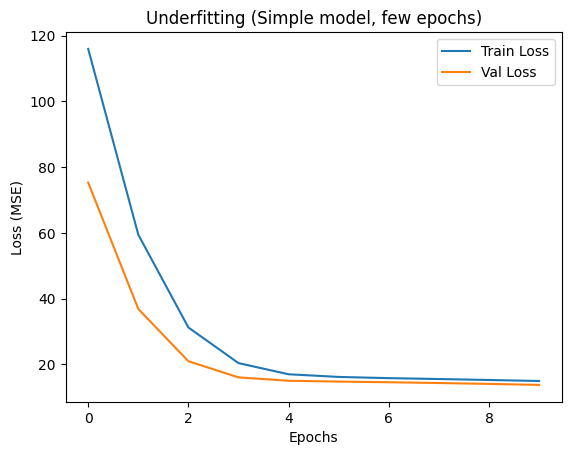

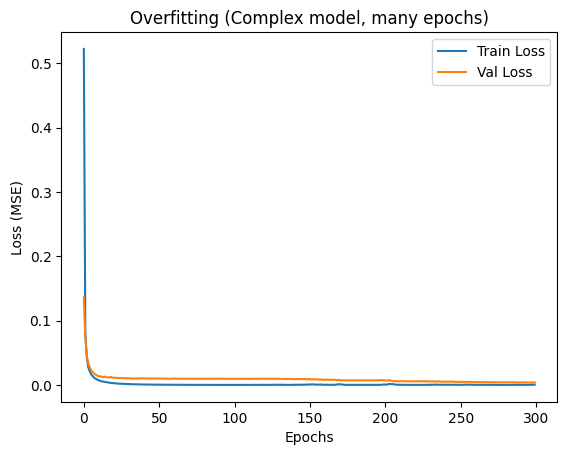

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generate synthetic dataset (features ~ study_hours, sleep_hours, attendance)
np.random.seed(42)
X = np.random.rand(1000, 30) * 10
y = (2*X[:,0] + 1.5*X[:,1] + 3*X[:,2] + np.random.randn(1000)*2)  # linear-ish relation
y = (y - y.min()) / (y.max() - y.min())  # normalize to 0-1

# Split into train/test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def plot_history(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.show()

# --------------------
# Underfitting Case
# --------------------
# Underfitting model
underfit_model = Sequential([
    Dense(1, input_dim=30, activation='linear')  # Too simple
])


underfit_model.compile(optimizer='adam', loss='mse')
underfit_history = underfit_model.fit(X_train, y_train, 
                                      validation_data=(X_val, y_val),
                                      epochs=10, batch_size=32, verbose=0)
plot_history(underfit_history, "Underfitting (Simple model, few epochs)")

# --------------------
# Overfitting Case
# --------------------
overfit_model = Sequential([
    Dense(128, activation='relu', input_dim=30),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

overfit_model.compile(optimizer='adam', loss='mse')
overfit_history = overfit_model.fit(X_train, y_train, 
                                    validation_data=(X_val, y_val),
                                    epochs=300, batch_size=32, verbose=0)
plot_history(overfit_history, "Overfitting (Complex model, many epochs)")
